In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import pyarrow.feather as feather

import matplotlib.pyplot as plt
import seaborn as sns 
from pathlib import Path

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from utils.utils import select_best_seasonal_smooth

# Import LSTM plotting utilities
from plots import plot_loss_curves, plot_data_distribution, plot_forecast_comparison

# Dataset Definition

## Training Visualization Features

The `MultiProductForecaster` uses plotting utilities from the `plots.py` module for comprehensive visualization during training.

### Plots Generated for Each Product:

1. **Data Distribution** (`data_distribution.png`):
   - Time series with train/val/test splits
   - Value distribution histograms by split
   - Box plots comparing splits
   - Detailed statistics summary

2. **Loss Curves** (`loss_curves.png`):
   - Training loss evolution
   - Validation loss evolution
   - Early stopping visualization

3. **Forecast Comparison** (`forecast_comparison.png`):
   - Forecast vs actual values
   - Zoomed test period detail
   - Distribution comparison (overall vs test vs forecast)
   - Error metrics (MAE, RMSE, MAPE)

All plots are saved to: `./training_plots/store_{store_id}_item_{item_id}/`

### Plotting Module

The plotting functions are located in `plots.py` and include:
- `plot_data_distribution()` - Visualize data splits and statistics
- `plot_loss_curves()` - Show training progress
- `plot_forecast_comparison()` - Compare predictions with actual values

These functions are called automatically during training when `save_plots=True`.


In [ ]:
subset_set= True 
dataset_imputed= False 
data_andre = False

selected_store = 6269


In [3]:
path = ''
if subset_set:
    path = '../dataset/subset_set.feather'
elif dataset_imputed:
    path = '../dataset/df_imputed.feather'
elif data_andre:
    path = '../dataset/data_andre.feather'

In [13]:
table = feather.read_table(path, memory_map=True)
df_selected = table.to_pandas()
#df_selected.head()



In [ ]:
# If 'date' is in the index, reset it
if 'date' not in df_selected.columns:
    if df_selected.index.name == 'date' or isinstance(df_selected.index, pd.DatetimeIndex):
        df_selected = df_selected.reset_index()
        print("\n✓ Date column recovered from index")

# Ensure date is datetime
if 'date' in df_selected.columns:
    df_selected['date'] = pd.to_datetime(df_selected['date'])
    print(f"✓ Date column is now datetime: {df_selected['date'].dtype}")
else:
    print("⚠️ Warning: 'date' column still missing!")

Columns in df_selected: ['item_id', 'value', 'cat_label', 'sdep_label', 'dep_label', 'dmn_label', 'promo_type_FRPG', 'promo_value_FRPG', 'promo_type_GAS', 'promo_value_GAS', 'promo_type_BOGO', 'promo_value_BOGO', 'promo_type_DISC', 'promo_value_DISC', 'promo_type_CIRC', 'promo_value_CIRC', 'promo_type_CIRE', 'promo_value_CIRE', 'promo_type_CLCP', 'promo_value_CLCP', 'promo_type_LFPE', 'promo_value_LFPE', 'store_id']

First few rows:
            item_id  value              cat_label              sdep_label  \
date                                                                        
2021-01-23    26008    104         sprd btr mrgrn    pos subd dairy other   
2021-01-23   921558     15   carbonated sft drnks  pos subd grocery other   
2021-01-23   213626     85  milknplant based bevs    pos subd dairy other   
2021-01-23   213625     44  milknplant based bevs    pos subd dairy other   
2021-01-23   213624     40  milknplant based bevs    pos subd dairy other   

                   dep_

In [6]:
TRAIN_RATIO = 0.6      # 60% train (and lookback)
VAL_RATIO = 0.2        # 20% validation
TEST_RATIO = 0.2       # 20% test (forecast horizon)
BATCH_SIZE = 32
HIDDEN_SIZE = 128
NUM_LAYERS = 2
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {DEVICE}")

Using device: cuda


In [7]:
class TimeSeriesDataset(Dataset):
    """Dataset for LSTM time series forecasting."""
    
    def __init__(self, data: pd.DataFrame, lookback: int, forecast_horizon: int, 
                 store_id: int = None, item_id: int = None,
                 include_features: List[str] = None):
        """
        Parameters
        ----------
        data : pd.DataFrame
            DataFrame with columns: date, store_id, item_id, value, and optional features
        lookback : int
            Number of past days to use as input
        forecast_horizon : int
            Number of days to forecast
        store_id, item_id : int, optional
            If provided, filter to specific store-item pair
        include_features : List[str], optional
            Additional feature columns to include (e.g., promo columns)
        """
        self.lookback = lookback
        self.forecast_horizon = forecast_horizon
        
        # Filter data if store/item specified
        if store_id is not None and item_id is not None:
            data = data[(data['store_id'] == store_id) & (data['item_id'] == item_id)].copy()
        
        # Sort by date
        data = data.sort_values('date').reset_index(drop=True)
        
        # Extract target (sales values)
        self.values = data['value'].values
        
        # Extract additional features if specified
        self.features = None
        if include_features:
            feature_cols = [col for col in include_features if col in data.columns]
            if feature_cols:
                self.features = data[feature_cols].values
        
        # Create sequences
        self.X, self.y = self._create_sequences()
        
    def _create_sequences(self):
        """Create input-output sequence pairs."""
        X, y = [], []
        
        for i in range(len(self.values) - self.lookback - self.forecast_horizon + 1):
            # Input: lookback window
            x_seq = self.values[i:i + self.lookback]
            
            # Include features if available
            if self.features is not None:
                x_features = self.features[i:i + self.lookback]
                x_seq = np.column_stack([x_seq, x_features])
            else:
                x_seq = x_seq.reshape(-1, 1)
            
            # Output: forecast horizon
            y_seq = self.values[i + self.lookback:i + self.lookback + self.forecast_horizon]
            
            X.append(x_seq)
            y.append(y_seq)
        
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.X[idx]), torch.FloatTensor(self.y[idx])







In [8]:
class LSTMForecaster(nn.Module):
    """LSTM model for multi-step forecasting."""
    
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, 
                 forecast_horizon: int, dropout: float = 0.2):
        """
        Parameters
        ----------
        input_size : int
            Number of input features (1 for univariate, >1 for multivariate)
        hidden_size : int
            LSTM hidden size
        num_layers : int
            Number of LSTM layers
        forecast_horizon : int
            Number of steps to forecast
        dropout : float
            Dropout rate
        """
        super(LSTMForecaster, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.forecast_horizon = forecast_horizon
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        # Output layer
        self.fc = nn.Linear(hidden_size, forecast_horizon)
        
    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor
            Shape: (batch_size, lookback, input_size)
        
        Returns
        -------
        torch.Tensor
            Shape: (batch_size, forecast_horizon)
        """
        # LSTM forward pass
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Use last hidden state for prediction
        last_hidden = h_n[-1]  # Shape: (batch_size, hidden_size)
        
        # Predict forecast horizon
        output = self.fc(last_hidden)  # Shape: (batch_size, forecast_horizon)
        
        return output


In [ ]:
class MultiProductForecaster:
    """Forecaster for multiple products with proper train/val/test split and visualization."""
    
    def __init__(self, train_ratio: float = 0.6, val_ratio: float = 0.2,
                 lookback_days: int = 60,  # Fixed lookback window
                 hidden_size: int = 128, num_layers: int = 2,
                 save_plots: bool = True, plots_base_dir: str = './training_plots'):
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio
        self.test_ratio = 1.0 - train_ratio - val_ratio
        self.lookback_days = lookback_days  # Fixed lookback (not dynamic)
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.models = {}
        self.scalers = {}
        self.forecast_horizons = {}
        self.save_plots = save_plots
        self.plots_base_dir = plots_base_dir
        
    def calculate_splits(self, total_length: int) -> Tuple[int, int, int]:
        """Calculate train/val/test split indices."""
        train_end = int(total_length * self.train_ratio)
        val_end = int(total_length * (self.train_ratio + self.val_ratio))
        test_length = total_length - val_end  # Forecast horizon
        return train_end, val_end, test_length
        
    def prepare_data(self, df: pd.DataFrame, store_id: int, item_id: int,
                    include_features: List[str] = None):
        """Prepare train/val/test datasets for a single product."""
        
        # Filter to store-item
        product_data = df[
            (df['store_id'] == store_id) & (df['item_id'] == item_id)
        ].sort_values('date').reset_index(drop=True)
        
        total_length = len(product_data)
        train_end, val_end, test_length = self.calculate_splits(total_length)
        forecast_horizon = test_length
        
        # Check if we have enough data
        min_required = self.lookback_days + forecast_horizon + 10  # Some margin
        if train_end < self.lookback_days + 10:
            print(f"Skipping item {item_id}: insufficient training data (need >{self.lookback_days + 10}, have {train_end})")
            return None, None, None, None, None, None
        
        # Plot data distribution before training
        if self.save_plots:
            plot_data_distribution(product_data, store_id, item_id, train_end, val_end, self.plots_base_dir)
        
        # Store forecast horizon for this product
        key = (store_id, item_id)
        self.forecast_horizons[key] = forecast_horizon
        
        # Scale the values
        scaler = StandardScaler()
        product_data['value_scaled'] = scaler.fit_transform(product_data[['value']])
        
        # Store scaler
        self.scalers[key] = scaler
        
        # Create temporary dataframe with scaled values
        temp_df = product_data.copy()
        temp_df['value'] = temp_df['value_scaled']
        
        # Split into train/val/test
        train_df = temp_df.iloc[:train_end]
        val_df = temp_df.iloc[:val_end]  # Val includes train data for sequence creation
        test_df = temp_df  # Test includes all data for sequence creation
        
        # Create datasets
        train_dataset = TimeSeriesDataset(
            train_df, self.lookback_days, forecast_horizon,
            store_id, item_id, include_features
        )
        
        val_dataset = TimeSeriesDataset(
            val_df, self.lookback_days, forecast_horizon,
            store_id, item_id, include_features
        )
        
        test_dataset = TimeSeriesDataset(
            test_df, self.lookback_days, forecast_horizon,
            store_id, item_id, include_features
        )
        
        print(f"  Total: {total_length} | Lookback: {self.lookback_days} | Train: {train_end} | Val: {val_end-train_end} | Test: {test_length} | Train sequences: {len(train_dataset)}")
        
        return train_dataset, val_dataset, test_dataset, scaler, forecast_horizon, product_data
    
    def train_product(self, store_id: int, item_id: int, 
                     train_dataset: Dataset, val_dataset: Dataset,
                     forecast_horizon: int, num_epochs: int = 50, 
                     learning_rate: float = 0.001, batch_size: int = 32,
                     early_stopping_patience: int = 10):
        """Train LSTM model for a single product with validation."""
        
        if train_dataset is None or len(train_dataset) == 0:
            return None, None
        
        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) if val_dataset and len(val_dataset) > 0 else None
        
        # Initialize model
        input_size = train_dataset.X.shape[2]
        model = LSTMForecaster(
            input_size=input_size,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            forecast_horizon=forecast_horizon
        ).to(DEVICE)
        
        # Loss and optimizer
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        
        # Training loop with validation
        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        patience_counter = 0
        best_model_state = None
        
        for epoch in range(num_epochs):
            # Training phase
            model.train()
            total_train_loss = 0
            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                
                # Forward pass
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                # Backward pass
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                total_train_loss += loss.item()
            
            avg_train_loss = total_train_loss / len(train_loader)
            train_losses.append(avg_train_loss)
            
            # Validation phase
            if val_loader:
                model.eval()
                total_val_loss = 0
                with torch.no_grad():
                    for X_batch, y_batch in val_loader:
                        X_batch = X_batch.to(DEVICE)
                        y_batch = y_batch.to(DEVICE)
                        outputs = model(X_batch)
                        loss = criterion(outputs, y_batch)
                        total_val_loss += loss.item()
                
                avg_val_loss = total_val_loss / len(val_loader)
                val_losses.append(avg_val_loss)
                
                # Early stopping check
                if avg_val_loss < best_val_loss:
                    best_val_loss = avg_val_loss
                    patience_counter = 0
                    best_model_state = model.state_dict().copy()
                else:
                    patience_counter += 1
                
                if (epoch + 1) % 10 == 0:
                    print(f"  Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")
                
                # Early stopping
                if patience_counter >= early_stopping_patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    break
            else:
                if (epoch + 1) % 10 == 0:
                    print(f"  Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}")
        
        # Load best model
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
        
        # Plot loss curves
        if self.save_plots:
            plot_loss_curves(train_losses, val_losses, store_id, item_id, self.plots_base_dir)
        
        # Store model
        key = (store_id, item_id)
        self.models[key] = model
        
        return model, {'train_losses': train_losses, 'val_losses': val_losses}
    
    def predict(self, store_id: int, item_id: int, 
                recent_data: pd.DataFrame) -> np.ndarray:
        """
        Generate forecast for a product (size = test set size = 20% of data).
        
        Parameters
        ----------
        store_id, item_id : int
            Product identifier
        recent_data : pd.DataFrame
            Recent data (at least lookback days) for the product
        
        Returns
        -------
        np.ndarray
            Forecast (unscaled) with length = forecast_horizon
        """
        key = (store_id, item_id)
        
        if key not in self.models:
            print(f"No model found for store {store_id}, item {item_id}")
            return None
        
        model = self.models[key]
        scaler = self.scalers[key]
        lookback = self.lookback_days
        
        # Prepare input
        product_data = recent_data[
            (recent_data['store_id'] == store_id) & 
            (recent_data['item_id'] == item_id)
        ].sort_values('date').tail(lookback)
        
        if len(product_data) < lookback:
            print(f"Insufficient recent data for item {item_id}")
            return None
        
        # Scale values
        values_scaled = scaler.transform(product_data[['value']])
        
        # Create input tensor
        X = torch.FloatTensor(values_scaled).unsqueeze(0).to(DEVICE)  # Shape: (1, lookback, 1)
        
        # Predict
        model.eval()
        with torch.no_grad():
            forecast_scaled = model(X).cpu().numpy()[0]
        
        # Inverse transform
        forecast = scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).flatten()
        
        return forecast
    
    def train_all_products(self, df: pd.DataFrame, store_id: int = None,
                          num_epochs: int = 50, learning_rate: float = 0.001):
        """Train models for all products in the dataset."""
        
        if store_id is not None:
            product_pairs = [(store_id, item_id) for item_id in df[df['store_id'] == store_id]['item_id'].unique()]
        else:
            product_pairs = df.groupby(['store_id', 'item_id']).size().index.tolist()
        
        results = {}
        
        print(f"\n{'='*80}")
        print(f"Training LSTM models for {len(product_pairs)} products")
        print(f"Lookback: {self.lookback_days} days | Train {self.train_ratio:.0%} | Val {self.val_ratio:.0%} | Test {self.test_ratio:.0%}")
        if self.save_plots:
            print(f"Plots will be saved to: {self.plots_base_dir}")
        print(f"{'='*80}\n")
        
        for i, (s_id, i_id) in enumerate(product_pairs):
            print(f"[{i+1}/{len(product_pairs)}] Training model for Store {s_id}, Item {i_id}")
            
            # Prepare data
            result_tuple = self.prepare_data(df, s_id, i_id)
            
            if result_tuple[0] is None:
                continue
            
            train_ds, val_ds, test_ds, scaler, forecast_horizon, product_data = result_tuple
            
            # Train model with validation
            model, losses = self.train_product(
                s_id, i_id, train_ds, val_ds, forecast_horizon,
                num_epochs=num_epochs, 
                learning_rate=learning_rate
            )
            
            # Generate forecast and plot comparison
            if model is not None:
                forecast = self.predict(s_id, i_id, df)
                if forecast is not None and self.save_plots:
                    _, val_end, _ = self.calculate_splits(len(product_data))
                    plot_forecast_comparison(product_data, forecast, s_id, i_id, val_end, self.plots_base_dir)
            
            results[(s_id, i_id)] = {
                'model': model,
                'losses': losses,
                'lookback': self.lookback_days,
                'train_size': len(train_ds) if train_ds else 0,
                'val_size': len(val_ds) if val_ds else 0,
                'test_size': len(test_ds) if test_ds else 0,
                'forecast_horizon': forecast_horizon
            }
        
        return results



In [ ]:
# Initialize forecaster with 60/20/20 split and plotting enabled
forecaster = MultiProductForecaster(
    train_ratio=TRAIN_RATIO,  # 60%
    val_ratio=VAL_RATIO,      # 20%
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    save_plots=True,          # Enable plot saving
    plots_base_dir='./training_plots'  # Directory for plots
)


results = forecaster.train_all_products(
    df_selected, 
    store_id=selected_store,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE
)

print(f"\n{'='*80}")
print(f"Training complete! Trained {len(results)} models.")
print(f"{'='*80}")

# Show lookback and forecast horizons
print("\nModel configurations per product:")
for (s_id, i_id), result_info in list(results.items())[:5]:
    print(f"  Store {s_id}, Item {i_id}: Lookback={result_info['lookback']} days, Forecast={result_info['forecast_horizon']} days")


Training LSTM models for 10 products
Lookback: 60 days | Train 60% | Val 20% | Test 20%
Plots will be saved to: ./training_plots

[1/10] Training model for Store 6269, Item 26008
  Total: 761 | Lookback: 60 | Train: 456 | Val: 152 | Test: 153 | Train sequences: 244
  Epoch [10/10], Train Loss: 0.962081, Val Loss: 0.908414
[2/10] Training model for Store 6269, Item 921558
  Total: 761 | Lookback: 60 | Train: 456 | Val: 152 | Test: 153 | Train sequences: 244
  Epoch [10/10], Train Loss: 1.092799, Val Loss: 1.119439
[3/10] Training model for Store 6269, Item 213626
  Total: 761 | Lookback: 60 | Train: 456 | Val: 152 | Test: 153 | Train sequences: 244
  Epoch [10/10], Train Loss: 1.105882, Val Loss: 1.062301
[4/10] Training model for Store 6269, Item 213625
  Total: 761 | Lookback: 60 | Train: 456 | Val: 152 | Test: 153 | Train sequences: 244
  Epoch [10/10], Train Loss: 0.669390, Val Loss: 0.692522
[5/10] Training model for Store 6269, Item 213624
  Total: 761 | Lookback: 60 | Train: 456

In [11]:
# Debug: Check why models weren't trained
print("Checking training results...")
print(f"Results dictionary has {len(results)} entries")

# Check if any models actually exist
models_trained = sum(1 for v in results.values() if v.get('model') is not None)
print(f"Models successfully trained: {models_trained}")

# Examine one product to see what went wrong
if len(results) > 0:
    first_key = list(results.keys())[0]
    first_result = results[first_key]
    print(f"\nFirst result for {first_key}:")
    for k, v in first_result.items():
        if k != 'model':
            print(f"  {k}: {v}")

# Check data availability for a specific product
sample_store = 6269
sample_item = 27
sample_data = df_selected[
    (df_selected['store_id'] == sample_store) & 
    (df_selected['item_id'] == sample_item)
]
print(f"\nSample product {sample_item} data:")
print(f"  Records: {len(sample_data)}")
if len(sample_data) > 0:
    print(f"  Date range: {sample_data['date'].min()} to {sample_data['date'].max()}")
    lookback_needed = int(len(sample_data) * 0.6)
    forecast_needed = int(len(sample_data) * 0.2)
    total_needed = lookback_needed + forecast_needed
    print(f"  Lookback needed (60%): {lookback_needed}")
    print(f"  Forecast needed (20%): {forecast_needed}")
    print(f"  Total needed: {total_needed}")
    print(f"  Sufficient data: {len(sample_data) >= total_needed}")

Checking training results...
Results dictionary has 10 entries
Models successfully trained: 10

First result for (6269, np.int64(26008)):
  losses: {'train_losses': [1.078732967376709, 1.0654803812503815, 1.0631759986281395, 1.0636924058198929, 1.0412462577223778, 1.0073799416422844, 0.9978562518954277, 0.985077366232872, 0.9703684821724892, 0.96208056807518], 'val_losses': [0.9092663343136127, 0.9390722169325902, 0.9239418667096359, 0.923106305874311, 0.901288662965481, 0.8943601044324728, 0.9130754952247326, 0.9076246687999139, 0.8874165117740631, 0.9084140474979694]}
  lookback: 60
  train_size: 244
  val_size: 396
  test_size: 549
  forecast_horizon: 153

Sample product 27 data:
  Records: 0



  Data Distribution.Png


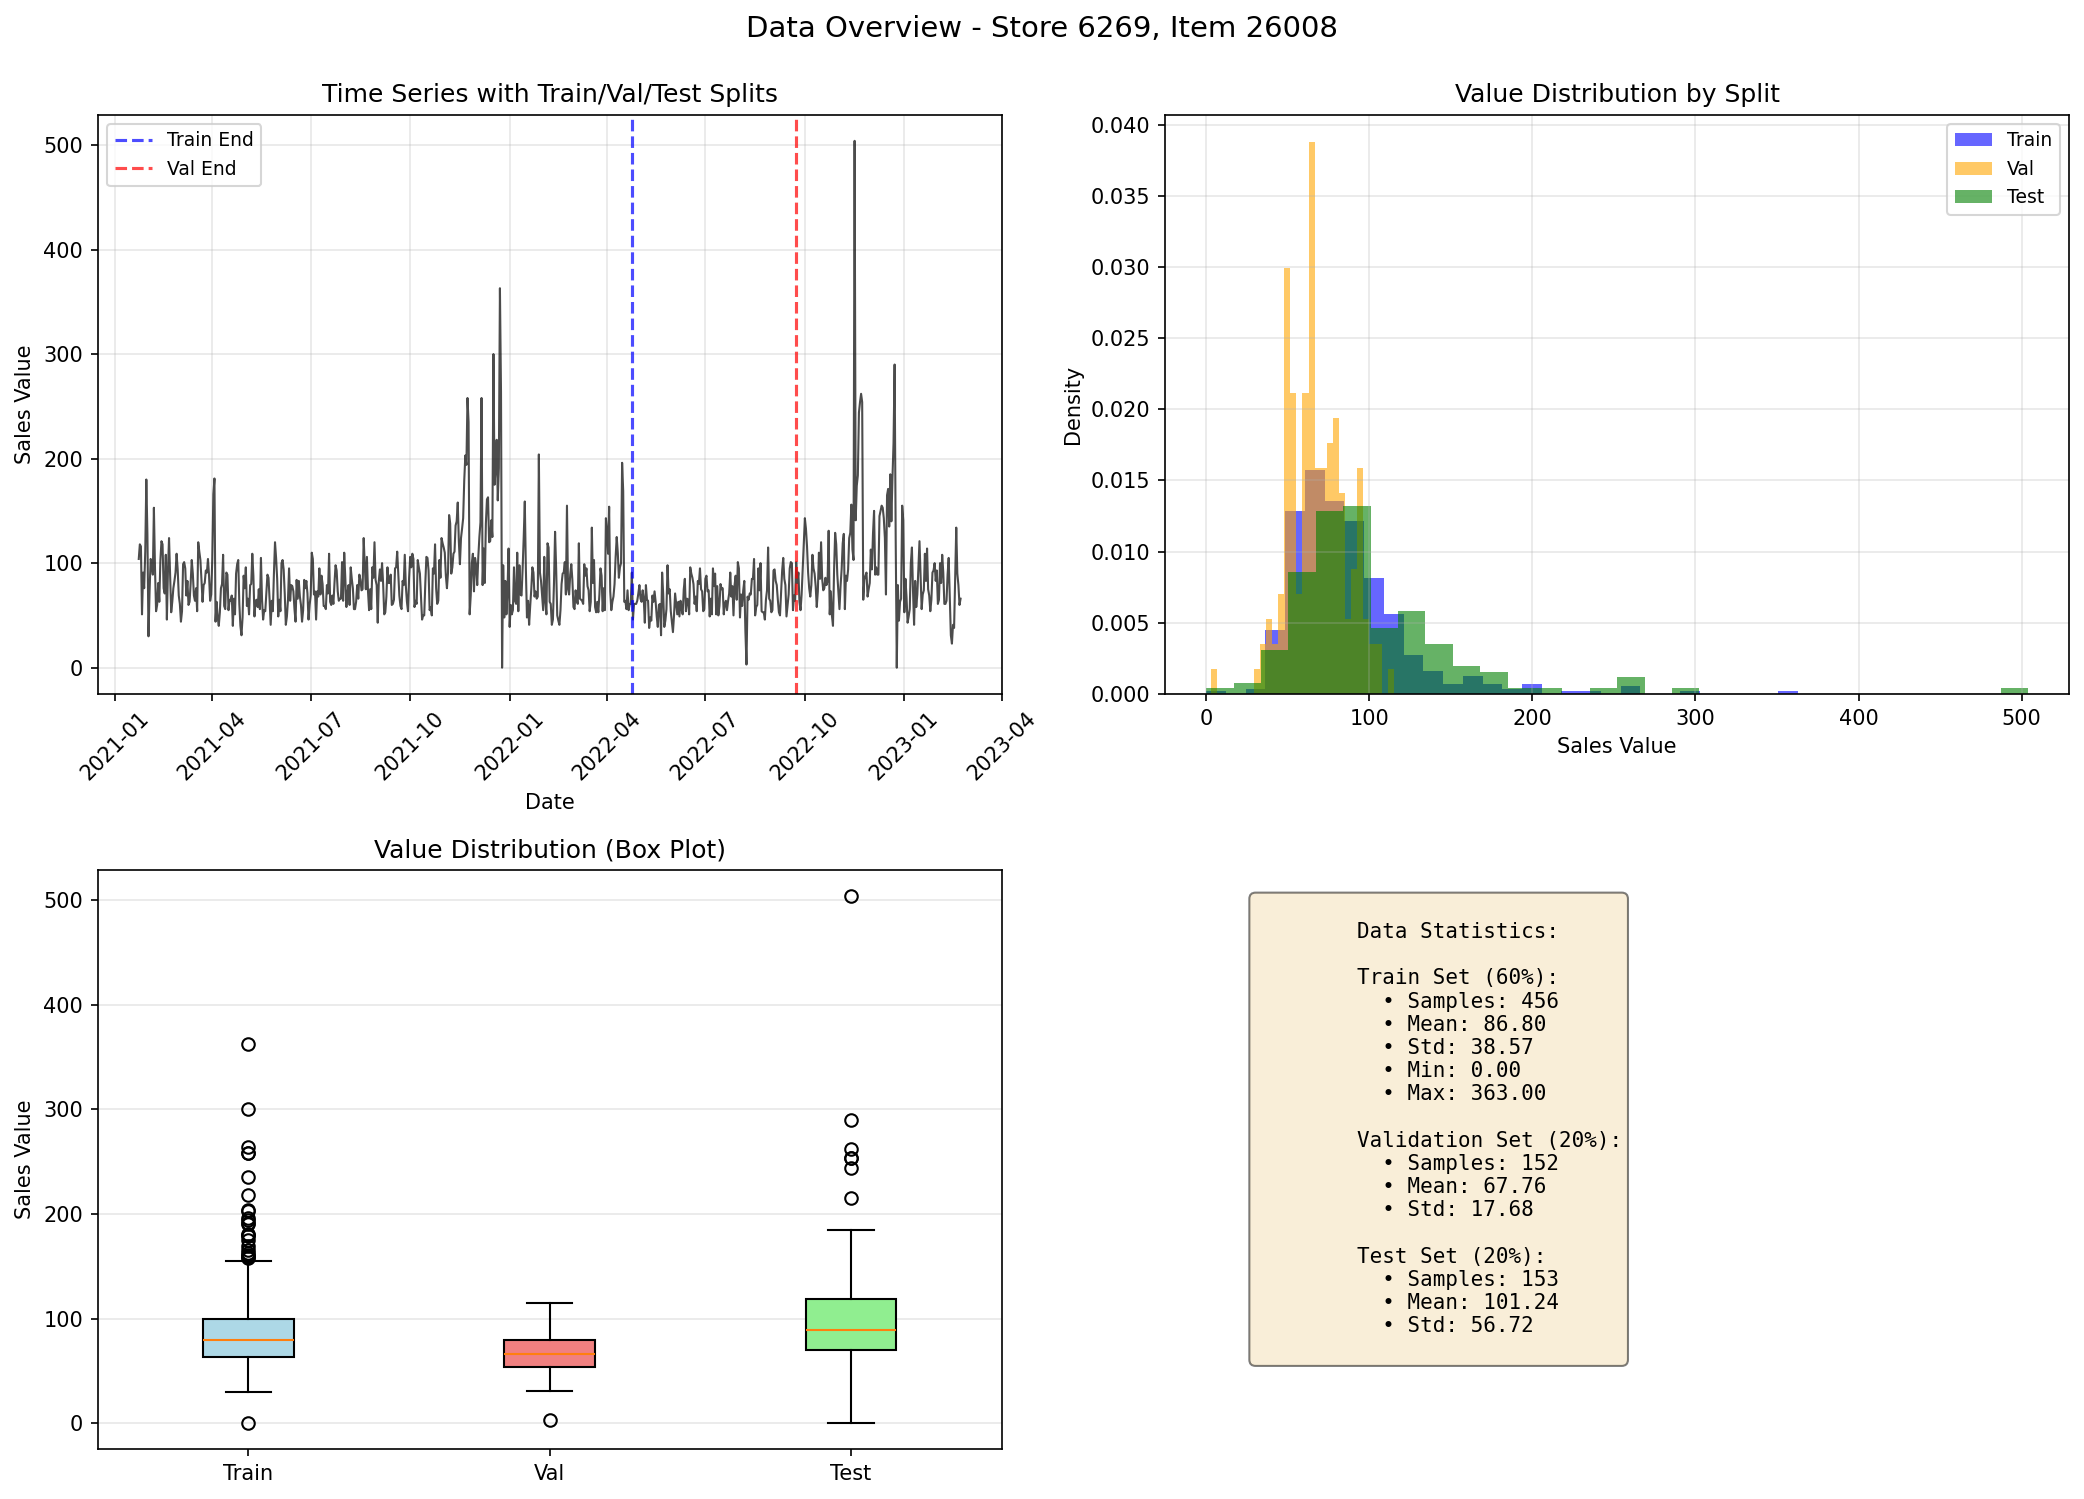


  Loss Curves.Png


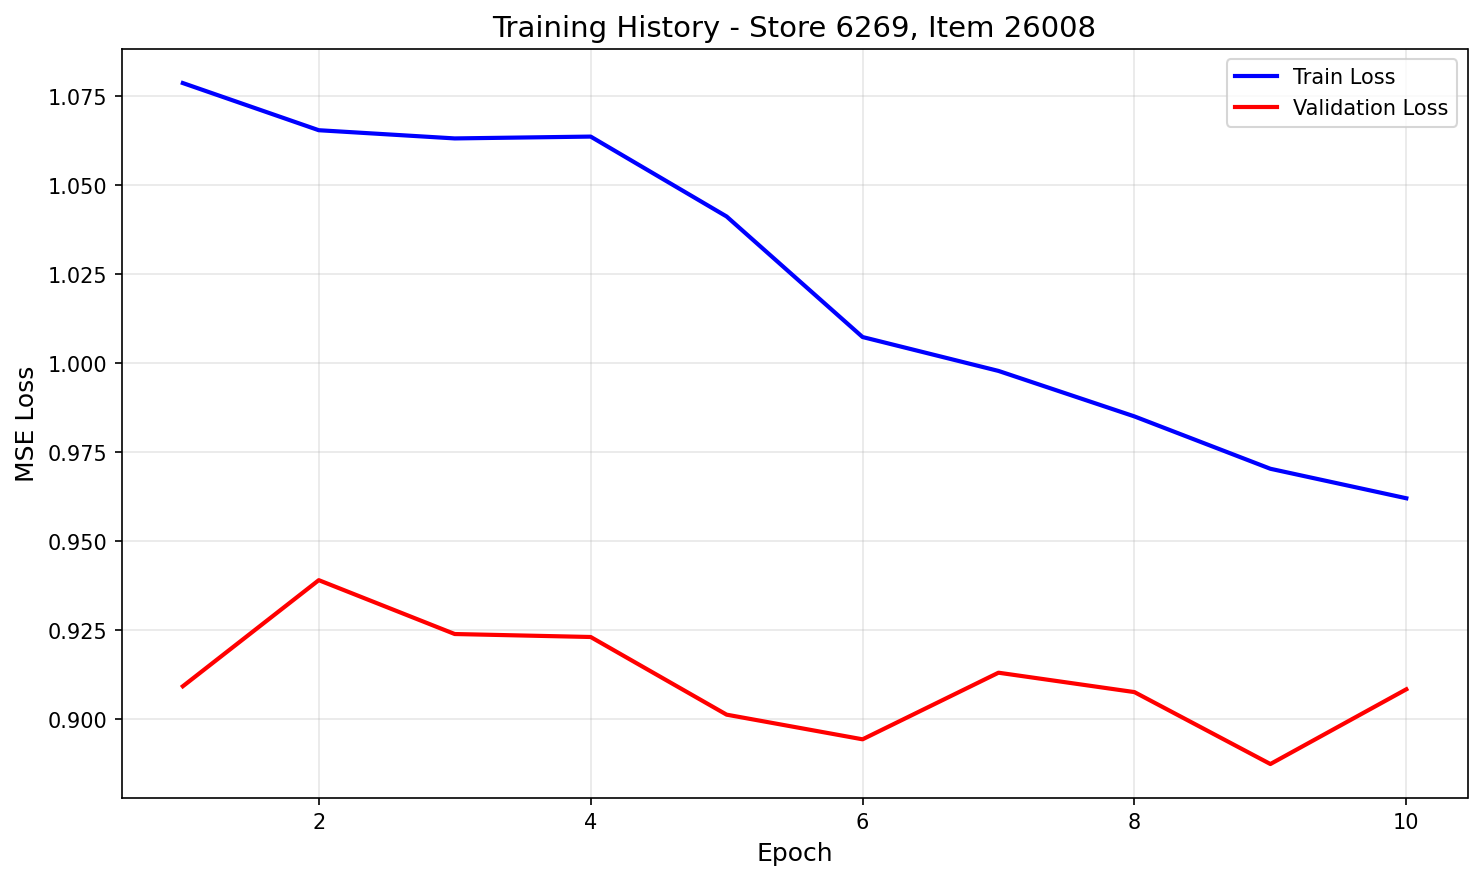


  Forecast Comparison.Png


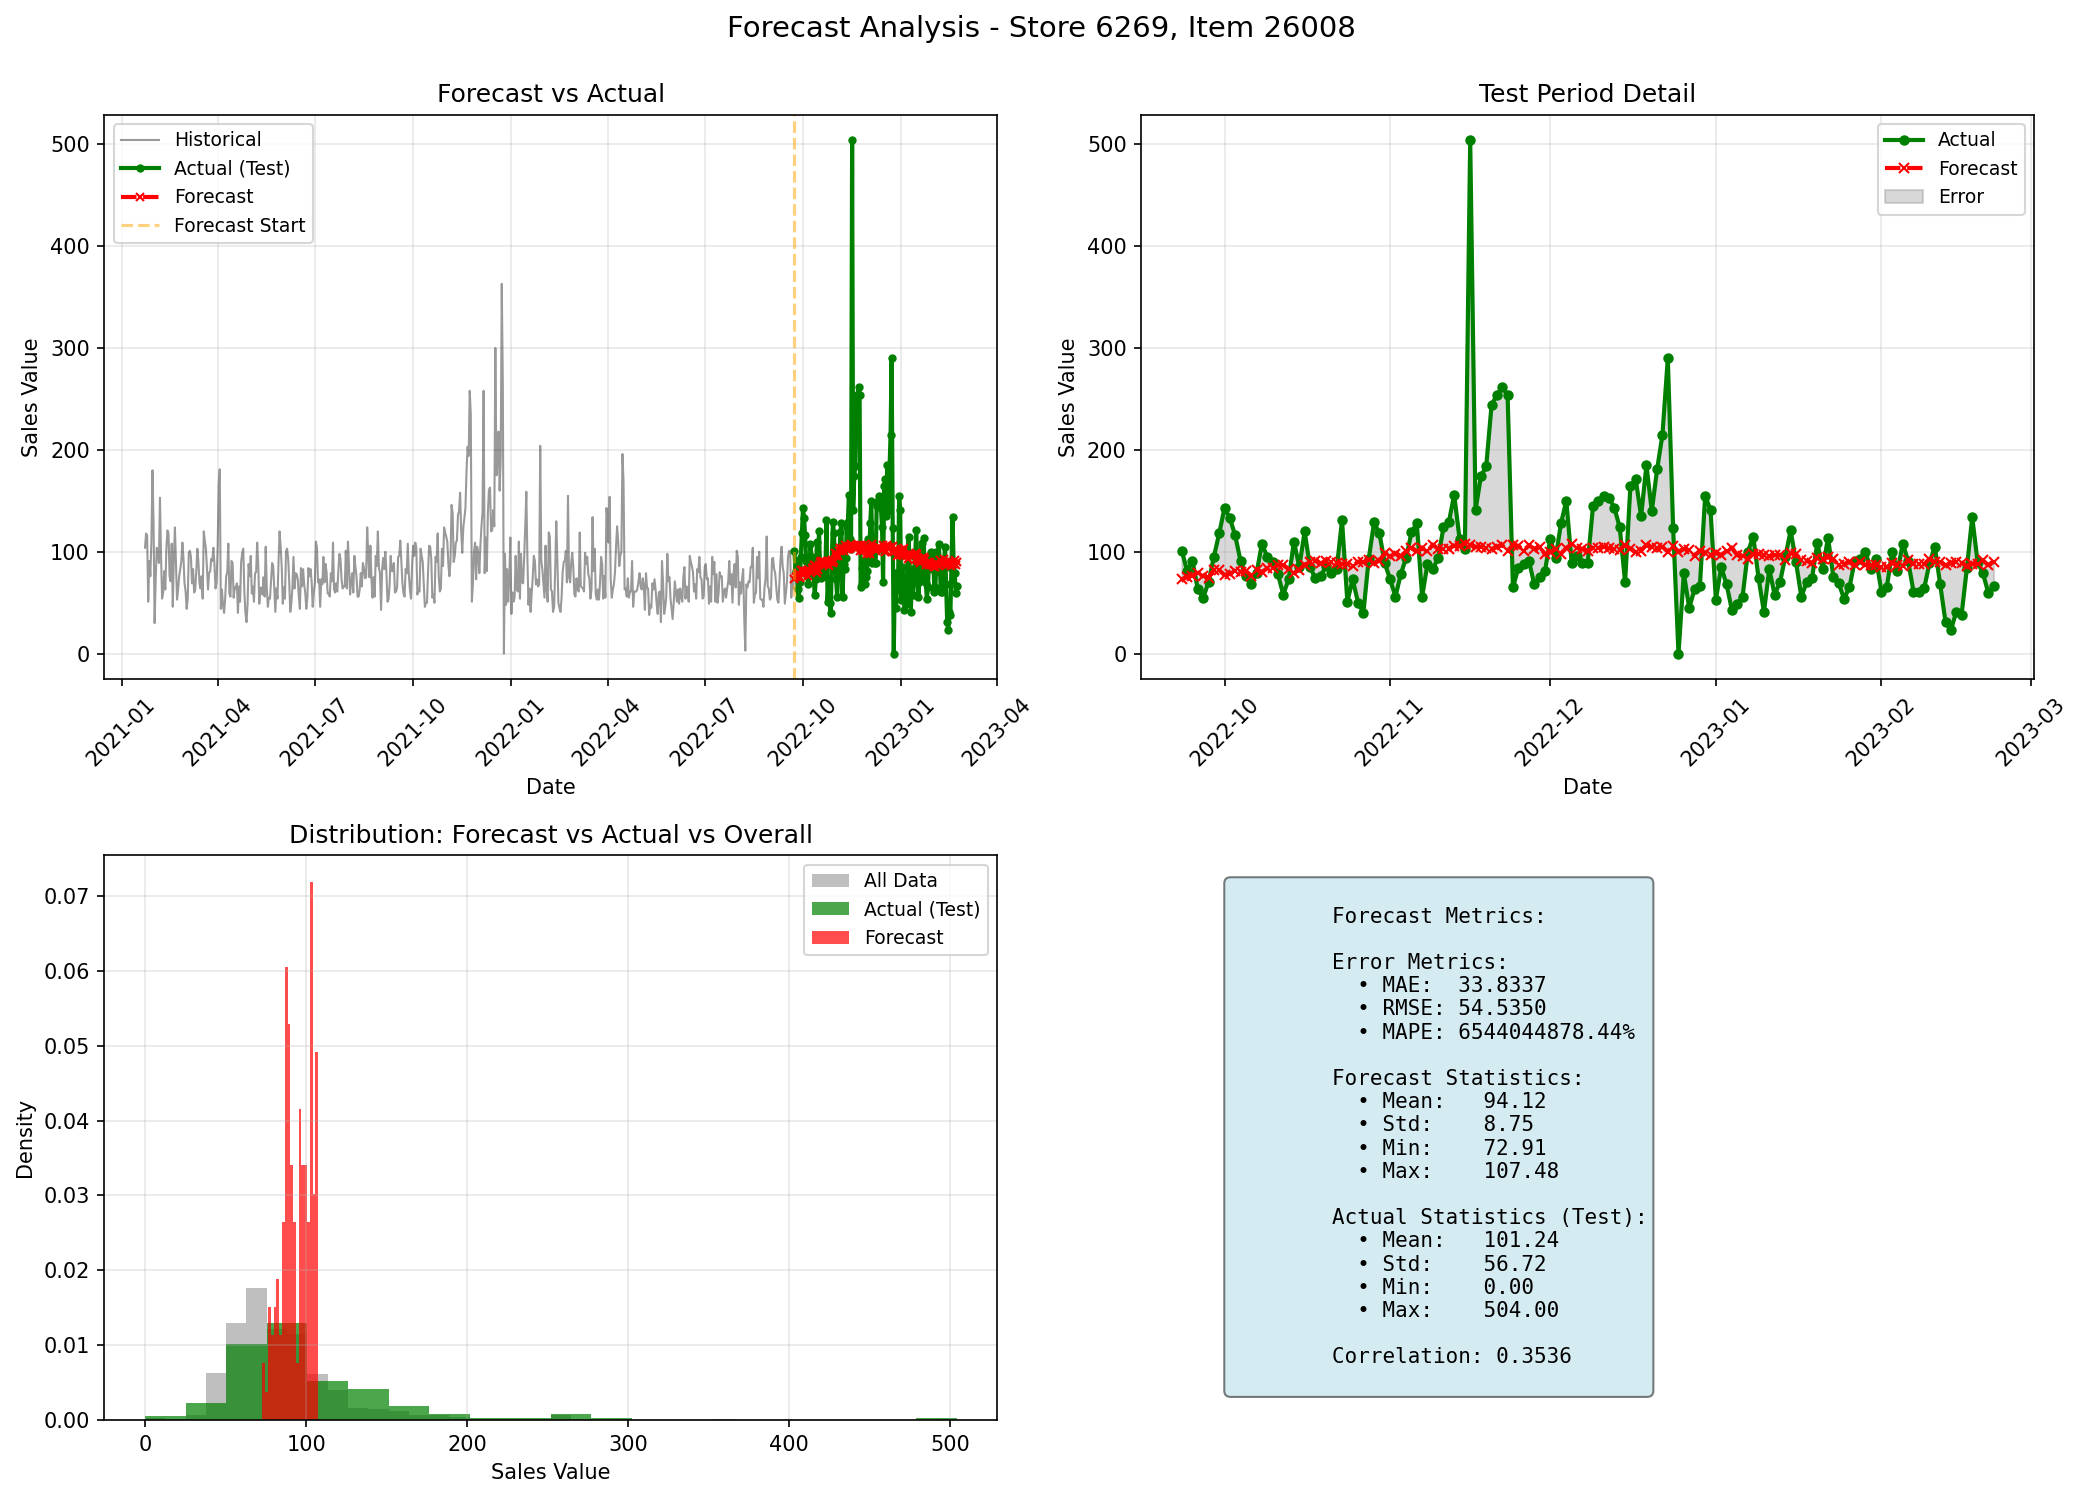

In [12]:
# View saved plots for a specific item
from IPython.display import Image, display
import os

def show_item_plots(store_id, item_id, plots_dir='./training_plots'):
    """Display all plots for a specific item."""
    item_dir = Path(plots_dir) / f"store_{store_id}_item_{item_id}"
    
    if not item_dir.exists():
        print(f"No plots found for Store {store_id}, Item {item_id}")
        return
    
    plot_files = ['data_distribution.png', 'loss_curves.png', 'forecast_comparison.png']
    
    for plot_file in plot_files:
        plot_path = item_dir / plot_file
        if plot_path.exists():
            print(f"\n{'='*80}")
            print(f"  {plot_file.replace('_', ' ').title().replace('.png', '')}")
            print('='*80)
            display(Image(filename=str(plot_path)))
        else:
            print(f"Plot not found: {plot_file}")

# Example: View plots for the first trained item
if len(results) > 0:
    first_item = list(results.keys())[0]
    show_item_plots(first_item[0], first_item[1])


## Visualize Training Results

Use the cell below to display all plots for any trained item. The plots are automatically saved during training.

**Tip**: To disable plot saving (for faster training), set `save_plots=False` when initializing the forecaster.
